# 🚁 RT-DETR Drone Detection (Kaggle Pipeline)

**Model:** RT-DETR-L (Transformer)
**Hardware:** Kaggle GPU (P100/T4)
**Dataset:** Input dataset from Kaggle

---

### 1. Setup Environment

In [1]:
# Install Dependencies
!pip install -q ultralytics

import os
import yaml
import glob

print("✅ Environment ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 54.9 MB/s eta 0:00:00
✅ Environment ready!


### 2. Configure Dataset Paths

**Note:** On Kaggle, your input dataset is automatically available at `/kaggle/input/`

In [2]:
# Kaggle automatically mounts datasets at /kaggle/input/
# Update this to match your dataset name on Kaggle
DATASET_NAME = 'Dron-Detection'  # Change this to your actual dataset name

# Find the dataset root
dataset_base = f'/kaggle/input/datasets/cybersimar08/drone-detection/drone-detection-new.v5-new-train.yolov8'

if not os.path.exists(dataset_base):
    print(f"⚠️ Dataset not found at {dataset_base}")
    print("Available datasets:")
    !ls /kaggle/input/
    raise FileNotFoundError(f"Please update DATASET_NAME variable to match your Kaggle dataset")

print(f"📍 Dataset found at: {dataset_base}")

# Find the data.yaml file
yaml_files = glob.glob(f'{dataset_base}/**/data.yaml', recursive=True)
if not yaml_files:
    yaml_files = glob.glob(f'{dataset_base}/**/*.yaml', recursive=True)

if not yaml_files:
    raise FileNotFoundError("Could not find data.yaml in the dataset!")

yaml_path = yaml_files[0]
dataset_root = os.path.dirname(yaml_path)
print(f"📍 Found config at: {yaml_path}")

# Read and display current config
with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)
    
print("\n📋 Current dataset config:")
print(f"  Classes: {data_config.get('nc', 'Unknown')}")
print(f"  Names: {data_config.get('names', 'Unknown')}")
print(f"  Train: {data_config.get('train', 'Unknown')}")
print(f"  Val: {data_config.get('val', 'Unknown')}")

📍 Dataset found at: /kaggle/input/datasets/cybersimar08/drone-detection/drone-detection-new.v5-new-train.yolov8
📍 Found config at: /kaggle/input/datasets/cybersimar08/drone-detection/drone-detection-new.v5-new-train.yolov8/data.yaml

📋 Current dataset config:
  Classes: 3
  Names: ['AirPlane', 'Drone', 'Helicopter']
  Train: ../train/images
  Val: ../valid/images


### 3. Create Working YAML Config

Since Kaggle datasets are read-only, we'll create a working copy

In [3]:
# Create a working directory for outputs
!mkdir -p /kaggle/working/config

# Create a new YAML with absolute paths for Kaggle
working_yaml = '/kaggle/working/config/data.yaml'

# Update paths to be absolute
data_config['path'] = dataset_root
data_config['train'] = 'train/images'
data_config['val'] = 'valid/images'

# Add test if it exists
if os.path.exists(os.path.join(dataset_root, 'test/images')):
    data_config['test'] = 'test/images'

# Write the working config
with open(working_yaml, 'w') as f:
    yaml.dump(data_config, f)

print(f"✅ Created working config at: {working_yaml}")
print("\n📋 Final config:")
with open(working_yaml, 'r') as f:
    print(f.read())

✅ Created working config at: /kaggle/working/config/data.yaml

📋 Final config:
names:
- AirPlane
- Drone
- Helicopter
nc: 3
path: /kaggle/input/datasets/cybersimar08/drone-detection/drone-detection-new.v5-new-train.yolov8
roboflow:
  license: MIT
  project: drone-detection-new-peksv
  url: https://universe.roboflow.com/ahmedmohsen/drone-detection-new-peksv/dataset/5
  version: 5
  workspace: ahmedmohsen
test: test/images
train: train/images
val: valid/images



### 4. Train RT-DETR Model

**Training Parameters:**
- Model: RT-DETR-L (Large)
- Epochs: 30
- Image Size: 640
- Batch Size: 8 (optimized for Kaggle GPU)

In [4]:
import shutil
import os

# 1. Update this path to match what you see in the sidebar under "Input"
# It usually looks like: /kaggle/input/[your-notebook-name]/[path-to-file]
source_path = '/kaggle/input/models/nikhil4043/last/other/default/1/last_detr.pt' 

# 2. Define where you want it to go
destination_path = '/kaggle/working/last.pt'

# 3. Copy it
if os.path.exists(source_path):
    shutil.copy(source_path, destination_path)
    print(f"✅ Recovered last.pt to: {destination_path}")
else:
    print(f"❌ Could not find file at {source_path}. Check the 'Input' sidebar path carefully.")

✅ Recovered last.pt to: /kaggle/working/last.pt


In [5]:
from ultralytics import RTDETR
import os

# 1. Define the path to your autosaved checkpoint
# Based on your previous project/name settings:
checkpoint_path = '/kaggle/working/runs/train/rtdetr_drone/weights/rdetr-1.pt'

# 2. Logic to load the correct model
if os.path.exists(checkpoint_path):
    print(f"🔄 Found checkpoint! Resuming from: {checkpoint_path}")
    model = RTDETR(checkpoint_path)  # Load the trained weights, not the empty ones
    resume_status = True
else:
    print("⚠️ Checkpoint not found. If you restarted the session, your files might be gone.")
    print("🚀 Starting fresh...")
    model = RTDETR('rtdetr-l.pt')
    resume_status = False

# 3. Train with resume=True
results = model.train(
    data=working_yaml,  # Ensure this variable is still defined in your notebook
    epochs=30,
    imgsz=640,
    batch=8,
    device=0,
    workers=2,
    project='/kaggle/working/runs/train',
    name='rtdetr_drone',
    exist_ok=True,
    amp=True,
    patience=10,
    save=True,
    save_period=5,
    cache=False,
    verbose=True,
    resume=resume_status  # <--- THIS IS THE KEY PARAMETER
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
⚠️ Checkpoint not found. If you restarted the session, your files might be gone.
🚀 Starting fresh...
Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/config/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:829: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/30      6.84G     0.7671      3.438     0.2224          7        640: 100% ━━━━━━━━━━━━ 1350/1350 1.4it/s 15:57<0.7s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 2.8it/s 13.4s0.3s
                   all        603        497      0.709      0.687      0.583       0.27

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:829: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/30      7.77G     0.6996     0.5364     0.1821          8        640: 100% ━━━━━━━━━━━━ 1350/1350 1.4it/s 15:38<0.7s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 3.1it/s 12.3s0.3s
                   all        603        497      0.726      0.724      0.691      0.329

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/30      7.86G     0.7065     0.5171       0.19          7        640: 0% ──────────── 0/1350  0.7s

...

      28/30         7G     0.4223     0.3824    0.09843          6        640: 100% ━━━━━━━━━━━━ 1350/1350 1.5it/s 15:31<0.7s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 3.1it/s 12.3s0.3s
                   all        603        497      0.949      0.929      0.911      0.584

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      29/30      7.87G     0.3309     0.3606    0.05587          6        640: 0% ──────────── 0/1350  0.7s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:829: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      29/30      7.91G     0.4161     0.3749    0.09693          5        640: 100% ━━━━━━━━━━━━ 1350/1350 1.5it/s 15:30<0.7s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 3.1it/s 12.4s0.3s
                   all        603        497      0.958      0.945      0.927      0.604

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      30/30         7G     0.6026     0.4096     0.1286          6        640: 0% ──────────── 0/1350  0.7s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:829: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:93.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      30/30         7G     0.4056     0.3723     0.0938          4        640: 100% ━━━━━━━━━━━━ 1350/1350 1.5it/s 15:31<0.7s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 3.1it/s 12.4s0.3s
                   all        603        497      0.963      0.959      0.946      0.609

30 epochs completed in 7.887 hours.
Optimizer stripped from /kaggle/working/runs/train/rtdetr_drone/weights/last.pt, 66.2MB
Optimizer stripped from /kaggle/working/runs/train/rtdetr_drone/weights/best.pt, 66.2MB

Validating /kaggle/working/runs/train/rtdetr_drone/weights/best.pt...
Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
rt-detr-l summary: 310 layers, 31,989,905 parameters, 0 gradients, 103.4 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 3.1it/s 12.4s0.3s
                   all        603        497      0.953      0.

### 5. Validate Model

In [6]:
print("📊 Running validation...\n")

# Validate on validation set
metrics = model.val()

print("\n📈 Validation Results:")
print(f"  mAP@0.5: {metrics.box.map50:.3f}")
print(f"  mAP@0.5:0.95: {metrics.box.map:.3f}")
print(f"  Precision: {metrics.box.mp:.3f}")
print(f"  Recall: {metrics.box.mr:.3f}")

📊 Running validation...

Ultralytics 8.4.31 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
rt-detr-l summary: 310 layers, 31,989,905 parameters, 0 gradients, 103.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 11.5±3.4 MB/s, size: 13.1 KB)
val: Scanning /kaggle/input/datasets/cybersimar08/drone-detection/drone-detection-new.v5-new-train.yolov8/valid/labels... 603 images, 110 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 603/603 458.3it/s 1.3s<0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/cybersimar08/drone-detection/drone-detection-new.v5-new-train.yolov8/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 2.8it/s 13.4s0.3s
                   all        603        497       0.95      0.964      0.951      0.621
              AirPlane        133        133      0.931       0.97      0.958      0.712
                 Drone        220      

### 6. Test on Random Images

In [7]:
from IPython.display import Image, display
import random

print("📊 Generating Predictions on Test Images...\n")

# Get test images
test_dir = os.path.join(dataset_root, 'valid/images')  # or 'test/images' if available
test_images = glob.glob(f"{test_dir}/*.jpg") + glob.glob(f"{test_dir}/*.png")

if test_images:
    # Pick 6 random images
    sample_images = random.sample(test_images, min(6, len(test_images)))
    
    print(f"Testing on {len(sample_images)} random images...\n")
    
    # Run predictions
    results_pred = model.predict(
        sample_images, 
        save=True, 
        conf=0.5,
        project='/kaggle/working/predictions',
        name='test_results'
    )
    
    print("\n✅ Predictions saved to: /kaggle/working/predictions/test_results/")
    
    # Display first result
    if results_pred:
        pred_path = '/kaggle/working/predictions/test_results/' + os.path.basename(sample_images[0])
        if os.path.exists(pred_path):
            print("\n👁️ Sample Prediction:")
            display(Image(filename=pred_path, width=600))
else:
    print("⚠️ No test images found.")

📊 Generating Predictions on Test Images...

Testing on 6 random images...


0: 640x640 1 Helicopter, 22.2ms
1: 640x640 1 Drone, 22.2ms
2: 640x640 1 AirPlane, 22.2ms
3: 640x640 1 Drone, 22.2ms
4: 640x640 1 Drone, 22.2ms
5: 640x640 1 Drone, 22.2ms
Speed: 1.3ms preprocess, 22.2ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /kaggle/working/predictions/test_results

✅ Predictions saved to: /kaggle/working/predictions/test_results/


### 7. Display Training Results

📈 Training Metrics:


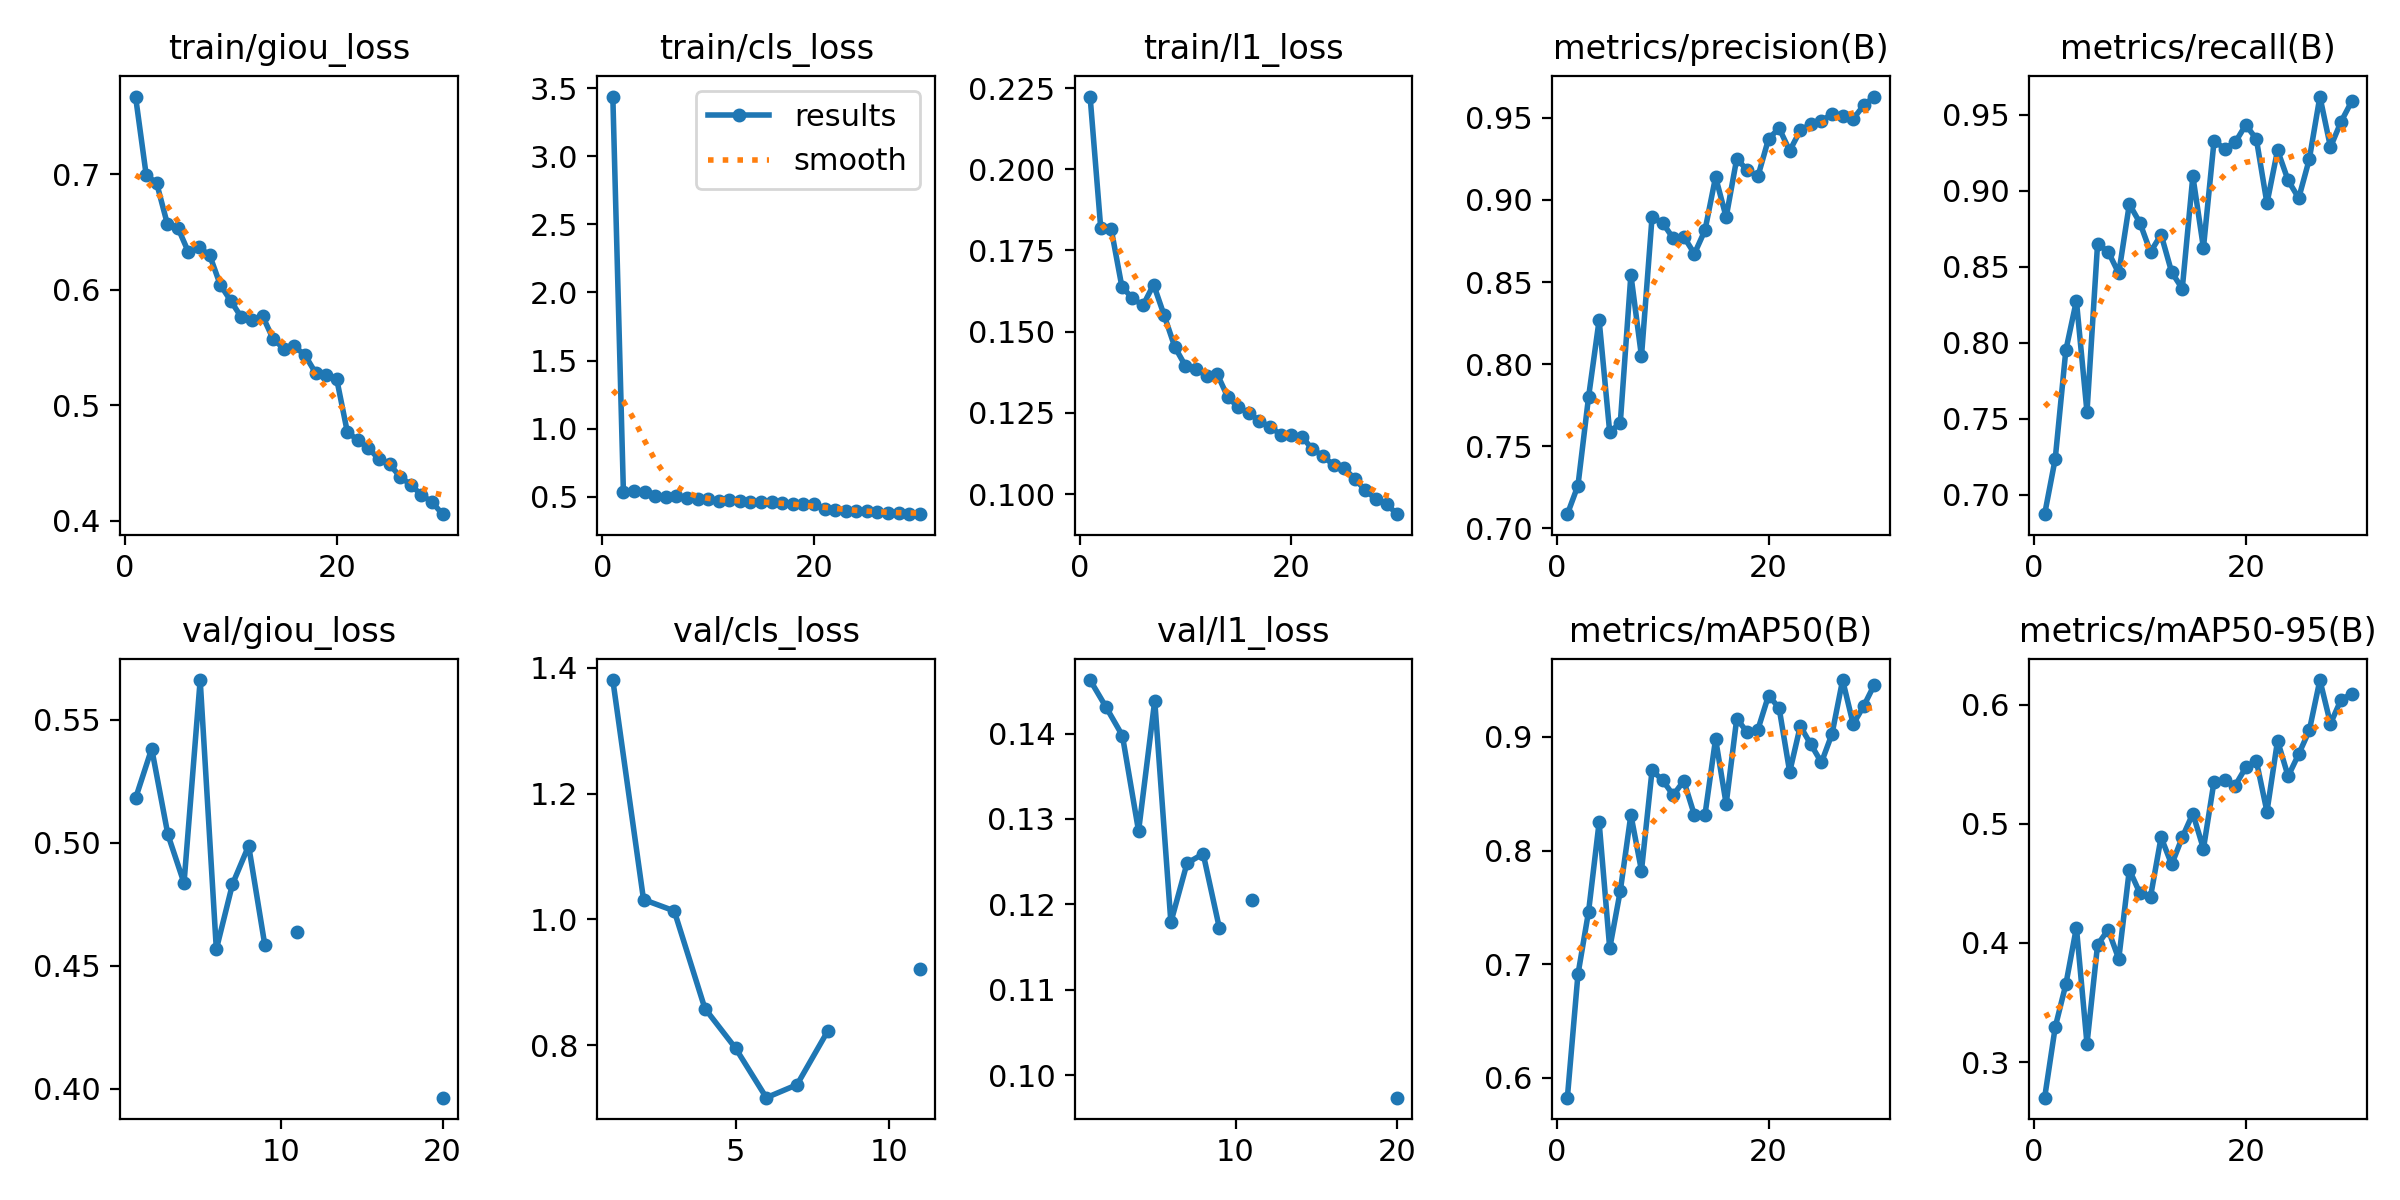


🎯 Confusion Matrix:


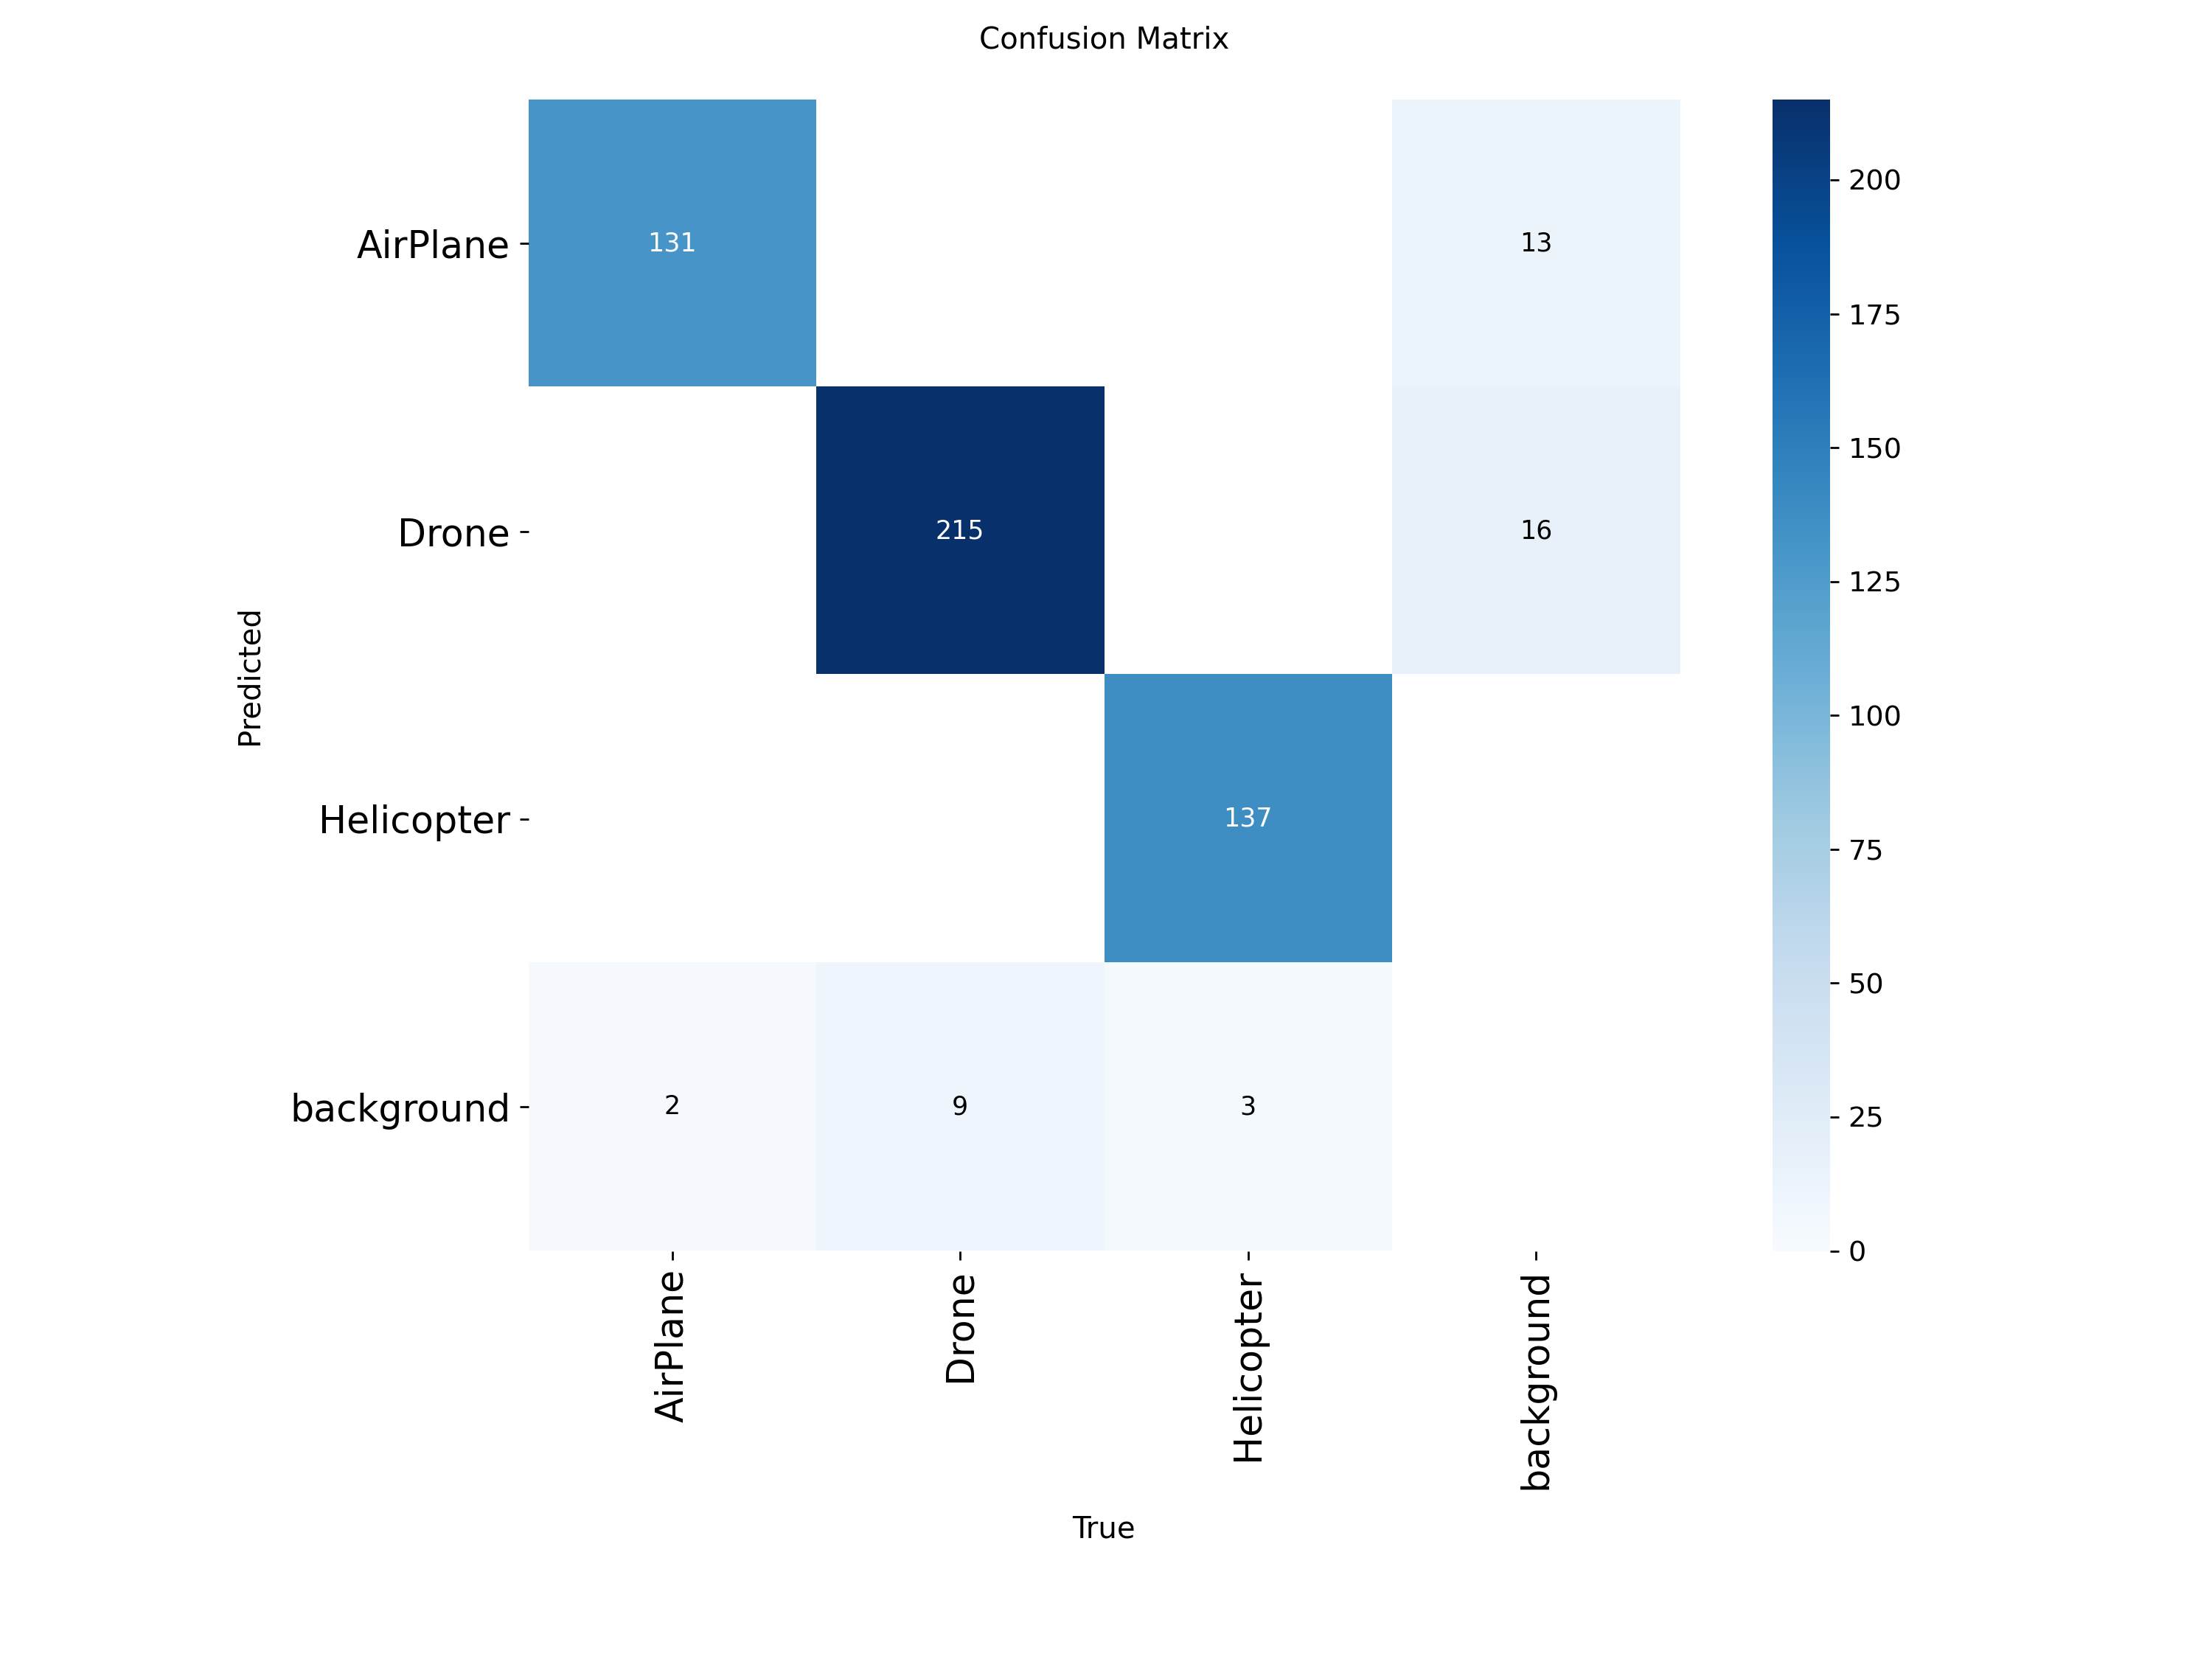

In [8]:
# Show training metrics
results_png = '/kaggle/working/runs/train/rtdetr_drone/results.png'
if os.path.exists(results_png):
    print("📈 Training Metrics:")
    display(Image(filename=results_png, width=1000))
else:
    print("⚠️ Results plot not found.")

# Show confusion matrix if available
confusion_matrix = '/kaggle/working/runs/train/rtdetr_drone/confusion_matrix.png'
if os.path.exists(confusion_matrix):
    print("\n🎯 Confusion Matrix:")
    display(Image(filename=confusion_matrix, width=600))

### 8. Save Model Weights

The best model weights are automatically saved in `/kaggle/working/runs/train/rtdetr_drone/weights/`

In [9]:
print("📦 Model weights saved at:")
print("  Best: /kaggle/working/runs/train/rtdetr_drone/weights/best.pt")
print("  Last: /kaggle/working/runs/train/rtdetr_drone/weights/last.pt")

# List all files in the weights directory
weights_dir = '/kaggle/working/runs/train/rtdetr_drone/weights/'
if os.path.exists(weights_dir):
    print("\n📁 Available weight files:")
    !ls -lh {weights_dir}
else:
    print("⚠️ Weights directory not found.")

📦 Model weights saved at:
  Best: /kaggle/working/runs/train/rtdetr_drone/weights/best.pt
  Last: /kaggle/working/runs/train/rtdetr_drone/weights/last.pt

📁 Available weight files:
total 1.3G
-rw-r--r-- 1 root root  64M Mar 30 16:54 best.pt
-rw-r--r-- 1 root root 189M Mar 30 09:17 epoch0.pt
-rw-r--r-- 1 root root 189M Mar 30 11:55 epoch10.pt
-rw-r--r-- 1 root root 189M Mar 30 13:14 epoch15.pt
-rw-r--r-- 1 root root 189M Mar 30 14:32 epoch20.pt
-rw-r--r-- 1 root root 189M Mar 30 15:51 epoch25.pt
-rw-r--r-- 1 root root 189M Mar 30 10:36 epoch5.pt
-rw-r--r-- 1 root root  64M Mar 30 16:54 last.pt
